In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [27]:
df=pd.read_excel("D:/finance_tracker/Finance_Tracker_Workshop_Excel.xlsx")
df

,Date,Category,Amount ($)
0,2025-01-16,Groceries,103.71
1,2025-02-13,Groceries,157.53
2,2025-01-27,Subscriptions,54.93
3,2025-01-21,Shopping,125.36
4,2025-02-03,Entertainment,99.22
...,...,...,...
745,2025-02-14,Travel,32.96
746,2025-01-31,Entertainment,158.68
747,2025-02-27,Bills,75.23
748,2025-01-01,Rent,84.12


In [28]:
pd.read_excel

<function pandas.io.excel._base.read_excel(io, sheet_name: 'str | int | list[IntStrT] | None' = 0, *, header: 'int | Sequence[int] | None' = 0, names: 'SequenceNotStr[Hashable] | range | None' = None, index_col: 'int | str | Sequence[int] | None' = None, usecols: 'int | str | Sequence[int] | Sequence[str] | Callable[[str], bool] | None' = None, dtype: 'DtypeArg | None' = None, engine: "Literal['xlrd', 'openpyxl', 'odf', 'pyxlsb', 'calamine'] | None" = None, converters: 'dict[str, Callable] | dict[int, Callable] | None' = None, true_values: 'Iterable[Hashable] | None' = None, false_values: 'Iterable[Hashable] | None' = None, skiprows: 'Sequence[int] | int | Callable[[int], object] | None' = None, nrows: 'int | None' = None, na_values=None, keep_default_na: 'bool' = True, na_filter: 'bool' = True, verbose: 'bool' = False, parse_dates: 'list | dict | bool' = False, date_parser: 'Callable | lib.NoDefault' = <no_default>, date_format: 'dict[Hashable, str] | str | None' = None, thousands: 's

In [29]:
df.head()

,Date,Category,Amount ($)
0,2025-01-16,Groceries,103.71
1,2025-02-13,Groceries,157.53
2,2025-01-27,Subscriptions,54.93
3,2025-01-21,Shopping,125.36
4,2025-02-03,Entertainment,99.22


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750 entries, 0 to 749
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Date        750 non-null    object 
 1   Category    750 non-null    object 
 2   Amount ($)  750 non-null    float64
dtypes: float64(1), object(2)
memory usage: 17.7+ KB


In [31]:
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.to_period('M')

In [32]:
category_summary = df.groupby('Category')['Amount ($)'].sum().sort_values(ascending=False)


In [33]:
monthly_spending = df.groupby('Month')['Amount ($)'].sum()
savings_goal = 5000
monthly_savings = savings_goal - monthly_spending
savings_percentage = (monthly_savings / savings_goal * 100).replace(np.inf, 0)


In [34]:
summary = pd.DataFrame({
    'Total Spending': monthly_spending,
    'Savings Achieved': monthly_savings,
    'Savings %': savings_percentage.round(2)
})

summary.to_excel("monthly_summary.xlsx")


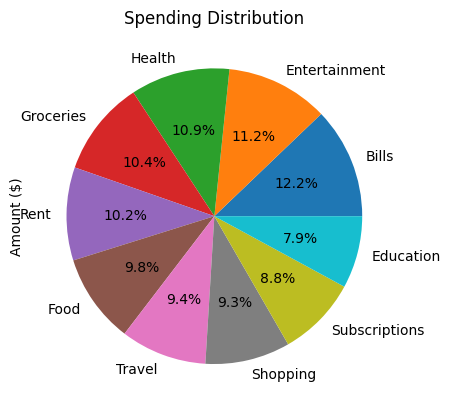

In [35]:
category_summary.plot(kind='pie', autopct='%1.1f%%')
plt.title("Spending Distribution")
plt.savefig("spending_pie_chart.png")
plt.show()


In [36]:
print("Top 3 Spending Categories:")
print(category_summary.head(3))

print("\nSavings % for Month:")
print(savings_percentage)

Top 3 Spending Categories:
Category
Bills            9441.07
Entertainment    8715.71
Health           8441.29
Name: Amount ($), dtype: float64

Savings % for Month:
Month
2025-01   -669.175
2025-02   -619.993
2025-03     35.119
Freq: M, Name: Amount ($), dtype: float64
